In [1]:
# Importa as bibliotecas usadas
import numpy as np
import pandas as pd
from astroquery.sdss import SDSS

import scipy.stats as stats
from scipy.optimize import curve_fit

from astropy.cosmology import Planck15

import matplotlib as mpl
from matplotlib import pyplot as plt

In [2]:
# Formatação dos plots
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams['font.size'] = 12
plt.rc('font', **{'family': 'serif', 'serif': ['Times']})
plt.rcParams["text.usetex"] = True 
mpl.rcParams['figure.dpi'] = 100
mpl.rcParams['legend.frameon'] = False #importante
mpl.rcParams['font.family'] = 'STIXGeneral'
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['xtick.direction'] = 'in' #importante
mpl.rcParams['ytick.direction'] = 'in' #importante
mpl.rcParams['xtick.top'] = True
mpl.rcParams['ytick.right'] = True
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.minor.size'] = 3
mpl.rcParams['xtick.major.width'] = 0.79
mpl.rcParams['xtick.minor.width'] = 0.79
mpl.rcParams['ytick.major.width'] = 0.79
mpl.rcParams['ytick.minor.width'] = 0.79

import bagpipes as pipes

Bagpipes: PyMultiNest import failed, fitting will use the Nautilus sampler instead.


### Lendo os dados do catálogo:

In [3]:
snap_to_z = pd.read_pickle('snap_to_z.pkl')
#etg_table = pd.read_pickle('mergers_ETGs.pkl')
etg_table = pd.read_pickle('catalogue_ETGs.pkl')

table_massformed = np.array(etg_table['mass'])
table_SFR = np.array(etg_table['SFR'])
table_sSFR = np.array(etg_table['sSFR'])
table_met = np.array(etg_table['metallicity'])
table_dispvel = np.array(etg_table['dispvel'])

#U, B, V, K, g, r, i, z
table_photometrics = np.array([etg_table['U'], etg_table['B'], etg_table['V'], etg_table['K'], 
                            etg_table['g'], etg_table['r'], etg_table['i'], etg_table['z']]).T

trees = np.array(etg_table['tree'])

In [4]:
num_gal = len(table_massformed)
num_gal

3619

#### Diagrama Cor-Magnitude e Cor-Cor TNG vs SDSS:

In [4]:
# Lendo dados do SPLUS já corrigidos da poeira da Via Láctea
splus_data = pd.read_csv("morphgal_corrected.csv")

In [5]:
query = """
SELECT TOP 1000
    G.objID, G.ra, G.dec, S.z as redshift,
    G.dered_u as u, G.dered_g as g, G.dered_r as r, G.dered_i as i, G.dered_z as z,
    G.modelMagErr_u, G.modelMagErr_g, G.modelMagErr_r, 
    G.modelMagErr_i, G.modelMagErr_z,
    Z.p_el as prob_elliptical
FROM Galaxy AS G
JOIN zooSpec AS Z ON G.objID = Z.objid
JOIN SpecObj AS S ON G.specObjID = S.specObjID
WHERE 
    Z.p_el > 0.9
    AND S.z < 0.05
    AND S.zWarning = 0
    AND (G.flags & dbo.fPhotoFlags('SATURATED')) = 0
    AND (G.flags & dbo.fPhotoFlags('BRIGHT')) = 0
    AND (G.flags & dbo.fPhotoFlags('NOPROFILE')) = 0
    AND G.modelMagErr_g < 0.05
    AND G.modelMagErr_r < 0.05
    AND G.modelMagErr_i < 0.05
    AND G.modelMagErr_u < 0.1  -- Filtro u é naturalmente mais ruidoso
    AND G.clean = 1
"""

resultado = SDSS.query_sql(query)

sdss_etgs = resultado.to_pandas()

# Decodificando o objID (que vem como bytes por padrão no astroquery)
sdss_etgs['objID'] = sdss_etgs['objID'].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)

print(sdss_etgs.head())

                 objID          ra       dec  redshift         u         g  \
0  1237648720148299897  160.144322 -0.909414  0.038993  17.23042  15.52964   
1  1237648720148627480  160.894756 -0.934242  0.038710  16.81561  14.89694   
2  1237648720149545106  163.062060 -0.955493  0.048990  18.17826  16.29467   
3  1237648720149217569  162.289475 -0.908549  0.038042  18.47842  16.68900   
4  1237648720681959427  152.741659 -0.502814  0.046003  16.95344  15.07202   

          r         i         z  modelMagErr_u  modelMagErr_g  modelMagErr_r  \
0  14.80112  14.44921  14.17272       0.011404       0.002702       0.002379   
1  14.02571  13.60672  13.29813       0.011364       0.002308       0.001988   
2  15.45571  15.06184  14.75215       0.021608       0.003624       0.002898   
3  15.85154  15.43895  15.10838       0.026726       0.004335       0.003377   
4  14.22606  13.83171  13.52918       0.011520       0.002405       0.002077   

   modelMagErr_i  modelMagErr_z  prob_elliptical  

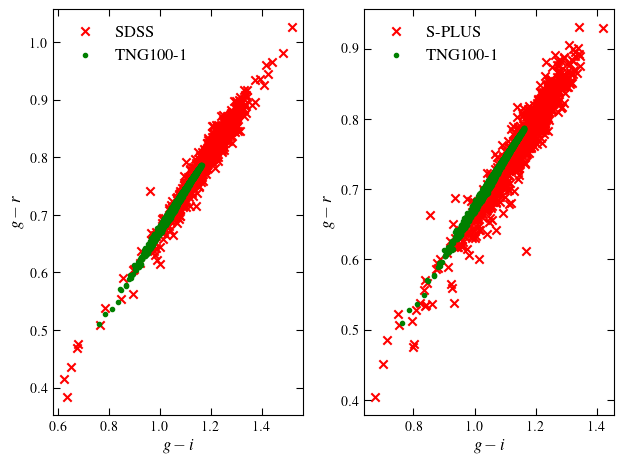

In [6]:
plt.subplot(1, 2, 1)
plt.scatter(sdss_etgs['g'] - sdss_etgs['i'], sdss_etgs['g'] - sdss_etgs['r'],
            c="red", marker="x", label="SDSS")

plt.scatter(etg_table['g'] - etg_table['i'], etg_table['g'] - etg_table['r'], 
            c="green", marker=".", label="TNG100-1")

plt.xlabel(r"$g - i$")
plt.ylabel(r"$g - r$")

plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(splus_data['g_auto'] - splus_data['i_auto'], splus_data['g_auto'] - splus_data['r_auto'],
            c="red", marker="x", label="S-PLUS")

plt.scatter(etg_table['g'] - etg_table['i'], etg_table['g'] - etg_table['r'], 
            c="green", marker=".", label="TNG100-1")

plt.xlabel(r"$g - i$")
plt.ylabel(r"$g - r$")

plt.legend()

plt.tight_layout()
plt.show()

### Estimação dos dados:

In [ ]:
def dbplaw(t, A, tau, alpha, beta):
    return A*((t/tau)**alpha + (t/tau)**-beta)**-1

<>:30: SyntaxWarning: invalid escape sequence '\o'
<>:30: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_11132/923448248.py:30: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('SFR [M$_\odot / yr$]')
/tmp/ipykernel_11132/2749534632.py:2: RuntimeWarning: overflow encountered in power
  return A*((t/tau)**alpha + (t/tau)**-beta)**-1


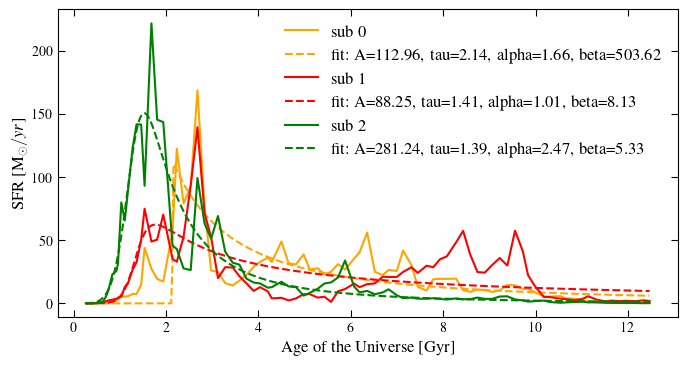

In [8]:
fig = plt.figure(figsize=(8,4))

colors = ['orange', 'red', 'green']
for i in range(0, 3):
    tree = trees[i]
    
    ages = []
    for num in tree['SnapNum']:
        redshift = snap_to_z["redshift"][num]
        universe_age = Planck15.age(redshift).value
        if universe_age == 0: universe_age = 1e-6
        ages.append(universe_age)
    
    ages = np.array(ages)
    sfr_data = tree['SubhaloSFR']
    
    # Plota os dados originais
    plt.plot(ages, sfr_data, '-', c=colors[i % 3], label='sub %d' % i)
    
    xdata = np.linspace(min(ages), max(ages), 500)

    initial_guesses = [max(sfr_data), np.median(ages), 2, 2]
    popt, pcov = curve_fit(dbplaw, ages, sfr_data, p0=initial_guesses, maxfev=20000)
    
    plt.plot(xdata, dbplaw(xdata, *popt), '--', c=colors[i % 3],
            label='fit: A=%.2f, tau=%.2f, alpha=%.2f, beta=%.2f' % tuple(popt))
    
    
plt.xlabel('Age of the Universe [Gyr]')
plt.ylabel('SFR [M$_\odot / yr$]')
plt.legend();

In [ ]:
tau = np.zeros(num_gal)
alpha = np.zeros(num_gal)
beta = np.zeros(num_gal)

for i in range(num_gal):
    tree = trees[i]
    
    ages = []
    for num in tree['SnapNum']:
        redshift = snap_to_z["redshift"][num]
        universe_age = Planck15.age(redshift).value
        if universe_age == 0: universe_age = 1e-6
        ages.append(universe_age)
    
    ages = np.array(ages)
    sfr_data = tree['SubhaloSFR']
    
    try:
        initial_guesses = [max(sfr_data), np.median(ages), 5, 0.01]
        popt, pcov = curve_fit(dbplaw, ages, sfr_data, p0=initial_guesses, maxfev=100000)
        
        tau[i] = popt[1]
        alpha[i] = popt[2]
        beta[i] = popt[3]
    except: 
        print(f"Subhalo {i} não convergiu.")
        tau[i] = -1

tree_df = pd.DataFrame()
tree_df['tau'] = tau
tree_df['alpha'] = alpha
tree_df['beta'] = beta

#tree_df.to_csv('merger_estimated.csv', index=False)
tree_df.to_csv('catalogue_estimated.csv', index=False)

In [9]:
#merger_data = pd.read_csv('merger_estimated.csv')
merger_data = pd.read_csv('catalogue_estimated.csv')
tau = np.array(merger_data['tau'])
alpha = np.array(merger_data['alpha'])
beta = np.array(merger_data['beta'])

tree_mask = (tau != -1) & (alpha < 1000) & (beta < 1000) \
            & (alpha > 0) & (beta > 0) & (tau > 1e-2)

etg_met = table_met[tree_mask]
etg_massformed = table_massformed[tree_mask]
etg_SFR = table_SFR[tree_mask]
etg_dispvel = table_dispvel[tree_mask]
alpha = alpha[tree_mask]
beta = beta[tree_mask]
tau = tau[tree_mask]

In [10]:
# Estimamos a função de densidade de probabilidade multivariada com o KDE
values = np.vstack([etg_met, np.log10(etg_massformed), 
                    np.log10(etg_dispvel), np.log10(tau), np.log10(alpha), np.log10(beta)])
kernel = stats.gaussian_kde(values, bw_method='silverman')

### Plots dos resultados:

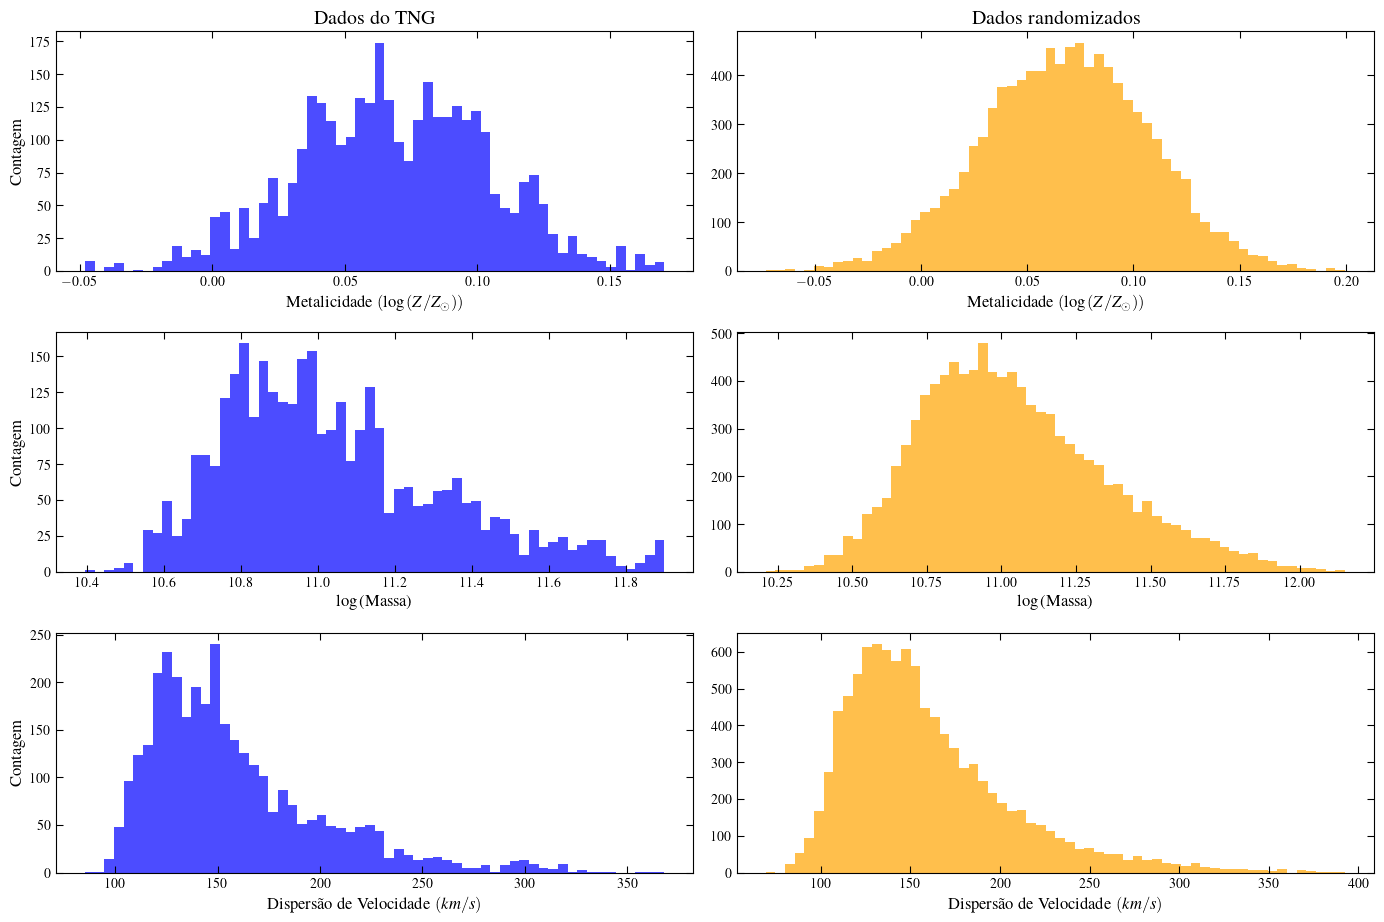

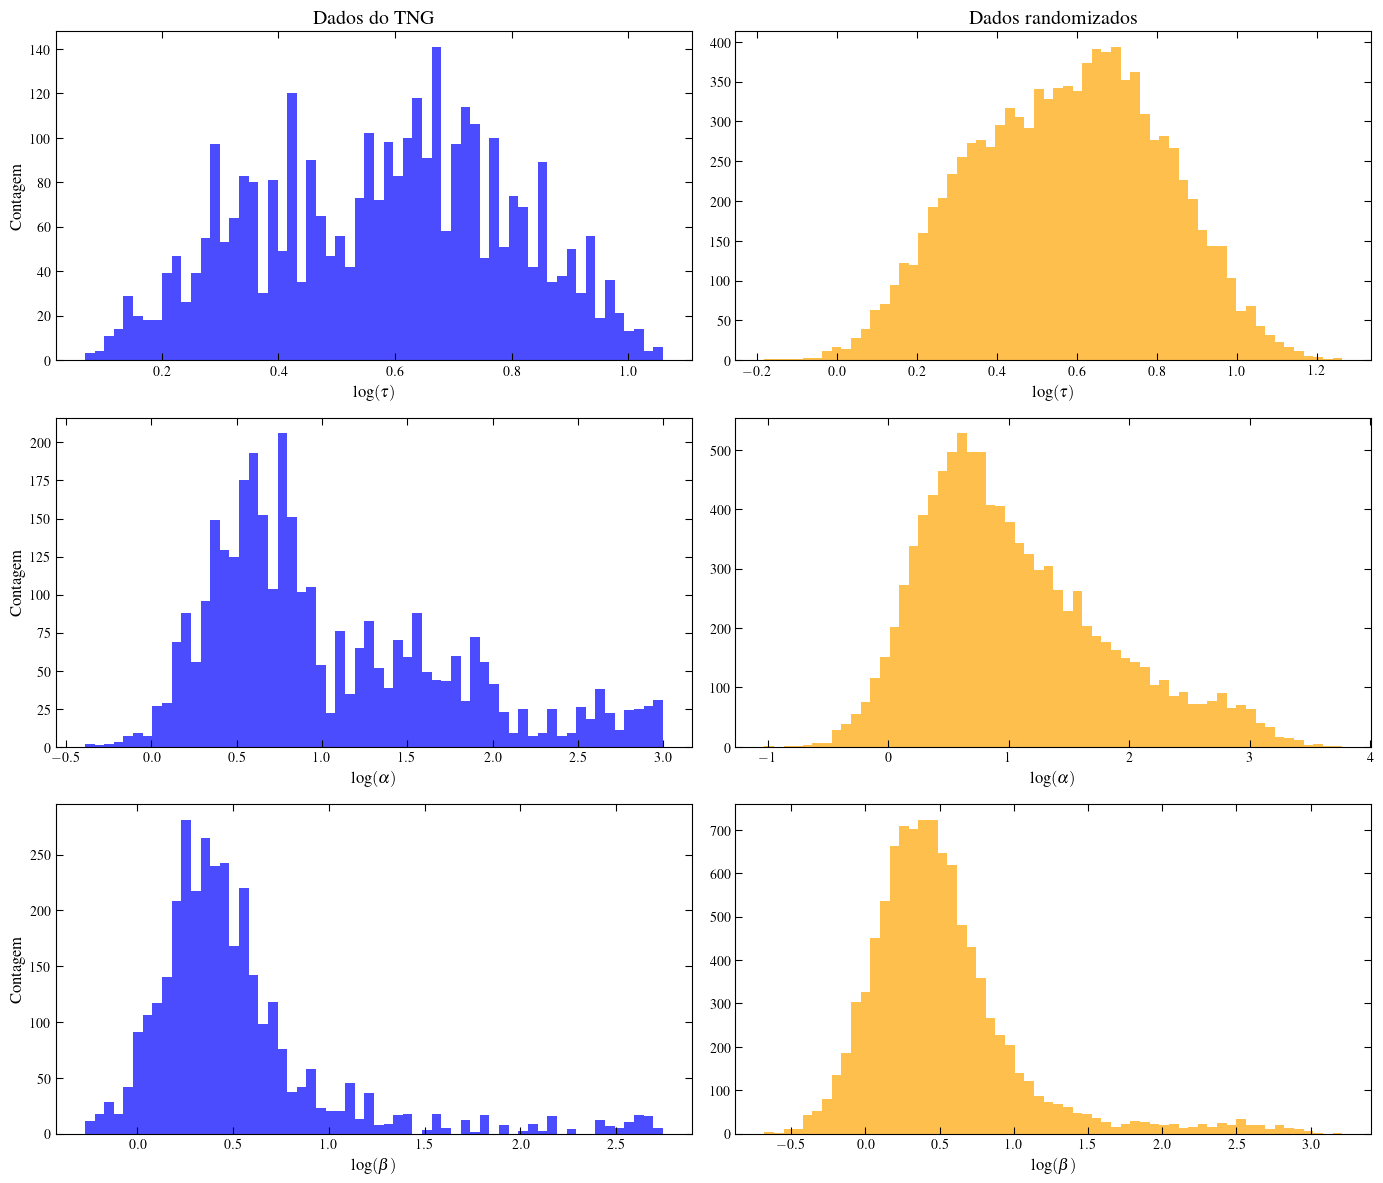

In [11]:
subplot_pos = 420

# Pega dados aleatórios baseados na distribuição original
def plot_mock(mock_data, data, name):
    global subplot_pos
    
    subplot_pos += 1
    plt.subplot(subplot_pos)
    plt.hist(data, bins=60, color='blue', alpha=0.7)
    plt.xlabel(name)
    plt.ylabel("Contagem")
    if (subplot_pos - 1) % 10 == 0: plt.title(f"Dados do TNG")
    
    subplot_pos += 1
    plt.subplot(subplot_pos)
    plt.hist(mock_data, bins=60, color='orange', alpha=0.7)
    plt.xlabel(name)
    if (subplot_pos - 2) % 10 == 0: plt.title(f"Dados randomizados")
    
# Reamostragem dos dados
mock_data = kernel.resample(10000)

#mock_SFR = (mock_data[2, :])[mock_data[2, :] >= 0]
#sfr_mask = (mock_data[2, :] >= 0)

mock_met = mock_data[0, :]
mock_mass = (mock_data[1, :])
mock_dispvel = 10**(mock_data[2, :])

mock_tau = 10**(mock_data[3, :])
mock_alpha = 10**(mock_data[4, :])
mock_beta = 10**(mock_data[5, :])

# Plot das figuras
fig = plt.figure(figsize=(14, 12))

plot_mock(mock_met, etg_met, r"Metalicidade $(\log{(Z/Z_{\odot})})$")
plot_mock(mock_mass, np.log10(etg_massformed), r"$\log{}$(Massa)")
#plot_mock(mock_SFR, etg_SFR, r"SFR $(M_{\odot} / yr)$")
plot_mock(mock_dispvel, etg_dispvel, r"Dispersão de Velocidade $(km/s)$")

plt.tight_layout()
plt.show()

# Plot da figura dos parametros da SFH
fig = plt.figure(figsize=(14, 12))
subplot_pos = 320

plot_mock(np.log10(mock_tau), np.log10(tau), r"$\log(\tau)$")
plot_mock(np.log10(mock_alpha), np.log10(alpha), r"$\log(\alpha)$")
plot_mock(np.log10(mock_beta), np.log10(beta), r"$\log(\beta)$")

plt.tight_layout()
plt.show()

In [12]:
len(mock_mass)

10000

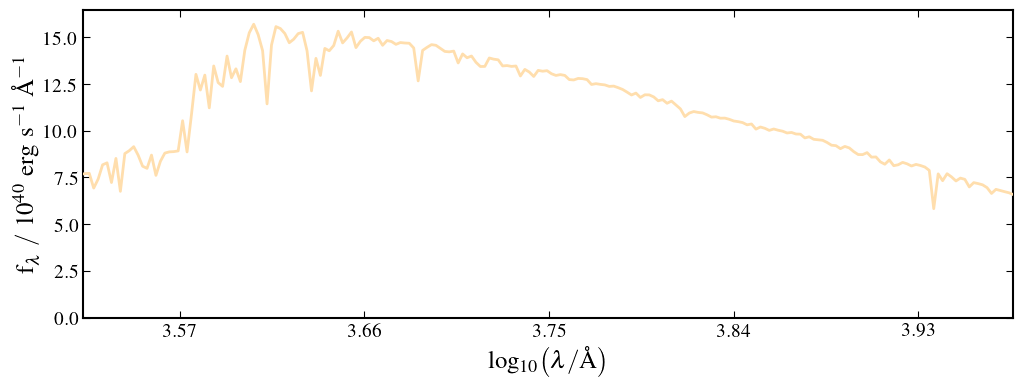

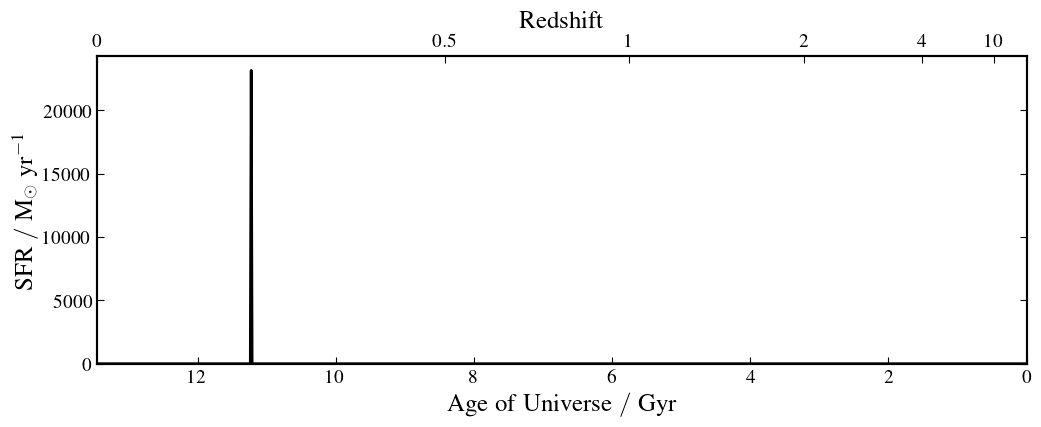

(<Figure size 1200x400 with 2 Axes>,
 <Axes: xlabel='$\\mathrm{Age\\ of\\ Universe\\ /\\ Gyr}$', ylabel='$\\mathrm{SFR\\ /\\ M_\\odot\\ \\mathrm{yr}^{-1}}$'>)

In [ ]:
from numpy import random as rnd

total_samples = 100
mock_photo_u = np.zeros(total_samples)
mock_photo_g = np.zeros(total_samples)
mock_photo_i = np.zeros(total_samples)
mock_photo_r = np.zeros(total_samples)
mock_photo_z = np.zeros(total_samples)

filt_list = np.loadtxt("splus-filters/splus_filters.txt", dtype="str")

# gera os modelos do bagpipes randomizados de acordo com as PDFs
for i in range(total_samples):
    index = rnd.randint(0, len(mock_mass))

    metallicity = mock_met[index]
    mass = mock_mass[index]
    dispvel = mock_dispvel[index]
    tau_mock = mock_tau[index]
    alpha_mock = mock_alpha[index]
    beta_mock = mock_beta[index]
    
    #print("Massa:", mass, "\nMetalicidade:", metallicity, "\nDispersão de Velocidade:", dispvel)
    
    dblplaw = {}
    dblplaw["massformed"] = mass
    dblplaw["metallicity"] = metallicity

    dblplaw["alpha"] = alpha_mock
    dblplaw["beta"] = beta_mock
    dblplaw["tau"] = tau_mock

    # Adicionar variação na poeira dependendo da metalicidade?
    dust = {}
    dust["type"] = "Calzetti"
    dust["Av"] = 0
    dust["eta"] = 3

    model_components = {}
    model_components["dblplaw"] = dblplaw
    model_components["dust"] = dust
    model_components["redshift"] = 0 # redshift observado --- REAMOSTRAR REDSHIFT FOTOMÉTRICO DO S-PLUS AQUI?
    model_components["t_bc"] = 0.01 # idade máxima da nuvem molecular de uma população jovem
    model_components["veldisp"] = dispvel # dispersao de velocidade em km/s

    model = pipes.model_galaxy(model_components, filt_list=filt_list, phot_units="mujy")
    mock_photo_u[i] = model.photometry[0]
    mock_photo_g[i] = model.photometry[5]
    mock_photo_r[i] = model.photometry[7]
    mock_photo_i[i] = model.photometry[9]
    mock_photo_z[i] = model.photometry[11]

model.plot()
model.sfh.plot()

#### Comparação dos dados do BAGPIPES com os dados do S-PLUS:

Query usada para a seleção dos dados do S-PLUS:

<pre>
SELECT morph_table.* FROM "dr3"."vac_morphgal" AS morph_table
JOIN "dr3"."vac_star_galaxy_quasar" AS class_table
    ON morph_table."ra" = class_table."RA"
    AND morph_table."dec" = class_table."DEC"
WHERE morph_table."probetg" > 0.9
    AND class_table."PROB_GAL" > 0.9
    AND morph_table."r_auto" < 21
    AND morph_table."g_auto" < 21
    AND morph_table."u_auto" < 21
    AND morph_table."i_auto" < 21
    AND morph_table."z_auto" < 21
    AND morph_table."e_r_auto" < 0.1
    AND morph_table."e_g_auto" < 0.1
    AND morph_table."e_u_auto" < 0.1
    AND morph_table."e_i_auto" < 0.1
    AND morph_table."e_z_auto" < 0.1
    AND morph_table."zml" < 0.1
    AND morph_table."zml_err" < 0.01
    AND morph_table."photoflag_r" = 0
</pre>

In [29]:
mock_photometry = np.array([mock_photo_u, mock_photo_g, mock_photo_r, mock_photo_i, mock_photo_z]).T

def flux_to_mag(flux):
    "Fluxo em microjansky para magnitude AB"
    mag_ab = -2.5 * np.log10(flux) + 23.9
    return mag_ab

mock_magnitudes = np.array([flux_to_mag(flux) for flux in mock_photometry.T])

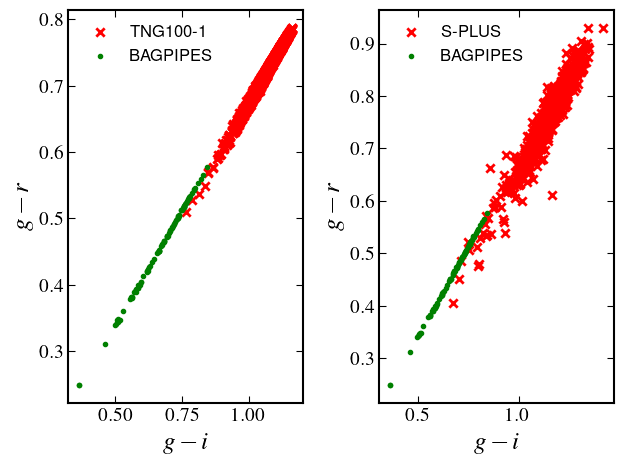

In [30]:
plt.subplot(1, 2, 1)
plt.scatter(etg_table['g'] - etg_table['i'], etg_table['g'] - etg_table['r'], 
            c="red", marker="x", label="TNG100-1")

plt.scatter(mock_magnitudes[1] - mock_magnitudes[3], mock_magnitudes[1] - mock_magnitudes[2],
            c="green", marker=".", label="BAGPIPES")

plt.xlabel(r"$g - i$")
plt.ylabel(r"$g - r$")

plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(splus_data['g_auto'] - splus_data['i_auto'], splus_data['g_auto'] - splus_data['r_auto'],
            c="red", marker="x", label="S-PLUS")

plt.scatter(mock_magnitudes[1] - mock_magnitudes[3], mock_magnitudes[1] - mock_magnitudes[2], 
            c="green", marker=".", label="BAGPIPES")

plt.xlabel(r"$g - i$")
plt.ylabel(r"$g - r$")

plt.legend()

plt.tight_layout()
plt.show()